In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
path = "results/{0}_fig7_rho_sub_critical_test_2.p"
#N_range = [int(n) for n in np.geomspace(1e5, 3e6, 10)]
N_range = [ 100000,  145923,  212936, 310723]
num_ensambles = 8
M = np.empty((len(N_range), num_ensambles))

In [79]:
for n in range(num_ensambles):
    with open(path.format(n), "rb") as f:
        mags = pickle.load(f)
        for N in range(len(N_range)):
            m = mags[N]
            M[N,n] = m

[0.44538558006619927, 0.03292, 0.4370937746552955, 0.041435619506763256]
[0.020360052904614078, 0.45524, 0.03797385129804261, 0.04015473589016584]
[0.4382653865394763, 0.03551, 0.034057181500544764, 0.028098982051537866]
[0.05526887468048217, 0.0467, 0.029238832325205695, 0.4416795666880147]
[0.03196891511276495, 0.05548615546455273, 0.03478, 0.031442796316976857]
[0.44811, 0.05156009317353571, 0.033476559555381945, 0.05380033019763584]
[0.0276, 0.04955353165710683, 0.030098245482210618, 0.4300711566250326]
[0.04079159935379645, 0.03690987712697793, 0.04515, 0.043830035111658935]


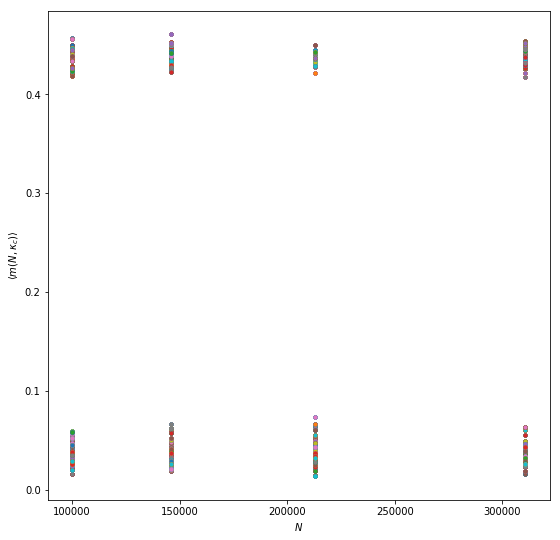

In [32]:
plt.figure(figsize=(9,9))
for n in range(num_ensambles):
    plt.scatter(N_range, M[:, n], s=10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\langle m(N, \kappa_c)\rangle$')
plt.show()

In [56]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= ms.size//4:
        pairs.append([N_range[N], -np.mean(md), np.std(md)])
        
pairs = np.array(pairs)

In [76]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= 0:#ms.size//4:
        pairs.append([N_range[N], N_range[N]*(np.mean(md**2)-np.mean(md)**2)])
        
pairs = np.array(pairs)

plt.loglog(*pairs[:,:2].T, 'ko')
plt.show()

[0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.43847447]
[0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167  

IndexError: too many indices for array

In [58]:
z = np.polyfit(np.log(pairs[:, 0]), np.log(pairs[:, 1]), 1)
print(z)
p = np.poly1d(z)

[ 2.20498494e-04 -9.62170599e-01]


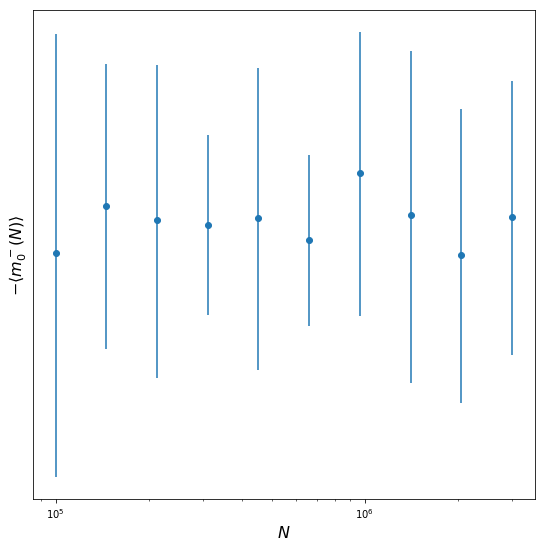

In [60]:
plt.figure(figsize=(9,9))
plt.errorbar(*pairs[:, :2].T, yerr=pairs[:, 2], fmt='o')
plt.plot(pairs[:, 0], p(np.log(pairs[:, 0])))
plt.ylabel(r'$-\langle m_0^-(N)\rangle$', fontsize=16)
plt.xlabel(r'$N$', fontsize=16)
plt.xscale('log')
#plt.yscale('log')
plt.show()

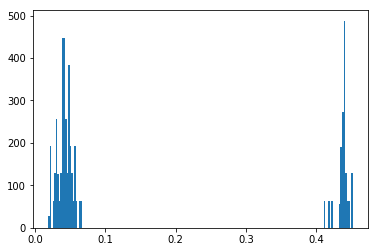

In [68]:
plt.hist(M[0,:], bins=200)
plt.show()